In [13]:
# Step 1: Import Required Libraries

import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [14]:
# Step 2: Upload Dataset from Laptop

from google.colab import files

uploaded = files.upload()

Saving Sentiment Module.csv to Sentiment Module (1).csv


In [15]:
# Load the uploaded CSV file

import io

file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully!")
print("File name:", file_name)

Dataset loaded successfully!
File name: Sentiment Module (1).csv


In [16]:
print(df.shape)

(5000, 4)


In [17]:
# Step 3: View the dataset

print("First 5 rows:")
display(df.head())

First 5 rows:


,id,text,sentiment,domain
0,1,आज मागवलेल्या पुस्तकाची छपाई आणि बांधणी दोन्ही...,Positive,ऑनलाइन व्यापार
1,2,जेवणात मिठाचे प्रमाण इतके जास्त होते की चवच बि...,Negative,उपाहारगृह
2,3,या चित्रपटाचा दुसरा भाग पुढील महिन्यात प्रदर्श...,Neutral,चित्रपट
3,4,उपचारानंतर माझी प्रकृती अपेक्षेपेक्षा लवकर सुध...,Positive,आरोग्यसेवा
4,5,प्रयोगशाळेतील अनेक उपकरणे आज बंद असल्यामुळे सर...,Negative,शिक्षण


In [18]:
print("\nLast 5 rows:")
display(df.tail())


Last 5 rows:


,id,text,sentiment,domain
4995,4996,त्याने काल पांढरा कोट घालणार आहे.,Neutral,स्वरूप
4996,4997,मी आज पांढरा कुर्ता घालणार आहे.,Neutral,स्वरूप
4997,4998,मी उद्या लाल शर्ट घेतला होता.,Neutral,स्वरूप
4998,4999,मी रात्री कॉफी बनवतो.,Neutral,अन्न
4999,5000,त्याने त्याचा सीव्ही अकाऊंटंट साठी एचआरला दिला...,Neutral,नोकरी


In [19]:
# Step 4: Check column names

print("Column names:")
print(df.columns.tolist())

Column names:
['id', 'text', 'sentiment', 'domain']


In [20]:
# Step 5: Check data types

print(df.dtypes)

id            int64
text         object
sentiment    object
domain       object
dtype: object


In [21]:
# Step 6: Check missing values

print(df.isnull().sum())

id           0
text         0
sentiment    0
domain       0
dtype: int64


In [22]:
print("\nTotal missing values:", df.isnull().sum().sum())


Total missing values: 0


In [23]:
# Step 7: Check duplicate rows

duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [24]:
duplicate_percentage = (duplicate_rows / len(df)) * 100

print("Duplicate percentage:", duplicate_percentage, "%")

Duplicate percentage: 0.0 %


In [25]:
# Step 8: Check duplicate text

duplicate_text = df['text'].duplicated().sum()

print("Duplicate text entries:", duplicate_text)

Duplicate text entries: 0


In [26]:
# Show duplicate texts if any

if duplicate_text > 0:
    display(df[df['text'].duplicated(keep=False)].sort_values('text'))
else:
    print("No duplicate texts found.")

No duplicate texts found.


In [27]:
# Step 9: Check duplicate text + sentiment combinations

duplicate_text_sentiment = df.duplicated(
    subset=['text', 'sentiment']
).sum()

print("Duplicate text + sentiment combinations:",
      duplicate_text_sentiment)

Duplicate text + sentiment combinations: 0


In [28]:
if duplicate_text_sentiment > 0:
    display(
        df[df.duplicated(
            subset=['text', 'sentiment'],
            keep=False
        )].sort_values(['text', 'sentiment'])
    )
else:
    print("No duplicate text + sentiment combinations found.")

No duplicate text + sentiment combinations found.


In [29]:
# Step 10: Check sentiment distribution

sentiment_counts = df['sentiment'].value_counts()

print(sentiment_counts)

sentiment
Positive    1672
Negative    1668
Neutral     1660
Name: count, dtype: int64


In [30]:
sentiment_percentage = df['sentiment'].value_counts(normalize=True) * 100

print("\nSentiment percentages:")
print(sentiment_percentage.round(2))


Sentiment percentages:
sentiment
Positive    33.44
Negative    33.36
Neutral     33.20
Name: proportion, dtype: float64


In [31]:
print("\nUnique sentiment labels:")
print(df['sentiment'].unique())


Unique sentiment labels:
['Positive' 'Negative' 'Neutral']


In [32]:
# Step 11: Validate sentiment labels

expected_labels = {'Positive', 'Negative', 'Neutral'}

actual_labels = set(df['sentiment'].unique())

print("Expected labels:", expected_labels)
print("Actual labels:", actual_labels)

if actual_labels == expected_labels:
    print("\nAll sentiment labels are valid!")
else:
    print("\nUnexpected sentiment labels found:")
    print(actual_labels - expected_labels)

Expected labels: {'Neutral', 'Negative', 'Positive'}
Actual labels: {'Neutral', 'Negative', 'Positive'}

All sentiment labels are valid!


In [33]:
# Step 12: Check domain distribution

domain_counts = df['domain'].value_counts()

print("Number of unique domains:", df['domain'].nunique())

print("\nDomain distribution:")
print(domain_counts)

Number of unique domains: 50

Domain distribution:
domain
स्वरूप              751
ऑनलाइन व्यापार      552
तंत्रज्ञान          324
अन्न                310
मनोरंजन             281
शिक्षण              280
प्रवास              163
क्रीडा              159
ग्राहक सेवा         144
सरकारी सेवा         142
चित्रपट             133
आरोग्यसेवा          130
बँकिंग              127
उपाहारगृह           126
शेती                125
वाहतूक              124
मोबाईल अॅप्स        120
सामाजिक माध्यमे     116
अन्न वितरण           94
सार्वजनिक वाहतूक     86
ऑनलाइन खरेदी         85
वेशभूषा              85
नोकरी                85
कार्यालय             77
संभाषण               60
हवामान               42
खरेदी                39
हॉटेल्स              30
रोजगार               30
व्यवसाय              28
भावना                26
स्थावर मालमत्ता      24
संवाद                21
आरोग्य               14
सण                    9
राजकारण               7
कुटुंब                6
सोशल मीडिया           6
रेस्टॉरंट             6
दैनंदि

In [34]:
domain_percentage = df['domain'].value_counts(normalize=True) * 100

print("\nDomain percentages:")
print(domain_percentage.round(2))


Domain percentages:
domain
स्वरूप              15.02
ऑनलाइन व्यापार      11.04
तंत्रज्ञान           6.48
अन्न                 6.20
मनोरंजन              5.62
शिक्षण               5.60
प्रवास               3.26
क्रीडा               3.18
ग्राहक सेवा          2.88
सरकारी सेवा          2.84
चित्रपट              2.66
आरोग्यसेवा           2.60
बँकिंग               2.54
उपाहारगृह            2.52
शेती                 2.50
वाहतूक               2.48
मोबाईल अॅप्स         2.40
सामाजिक माध्यमे      2.32
अन्न वितरण           1.88
सार्वजनिक वाहतूक     1.72
ऑनलाइन खरेदी         1.70
वेशभूषा              1.70
नोकरी                1.70
कार्यालय             1.54
संभाषण               1.20
हवामान               0.84
खरेदी                0.78
हॉटेल्स              0.60
रोजगार               0.60
व्यवसाय              0.56
भावना                0.52
स्थावर मालमत्ता      0.48
संवाद                0.42
आरोग्य               0.28
सण                   0.18
राजकारण              0.14
कुटुंब               0.12
सोशल मीडिय

In [35]:
# Step 13: Check empty or whitespace-only text

empty_text = df['text'].astype(str).str.strip().eq('').sum()

print("Empty or whitespace-only text:", empty_text)

Empty or whitespace-only text: 0


In [36]:
empty_sentiment = df['sentiment'].astype(str).str.strip().eq('').sum()
empty_domain = df['domain'].astype(str).str.strip().eq('').sum()

print("Empty sentiment:", empty_sentiment)
print("Empty domain:", empty_domain)

Empty sentiment: 0
Empty domain: 0


In [37]:
# Step 14: Clean extra spaces

df['text'] = df['text'].str.strip()
df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True)

df['sentiment'] = df['sentiment'].str.strip()
df['domain'] = df['domain'].str.strip()

print("Text and categorical columns cleaned successfully!")

Text and categorical columns cleaned successfully!


In [38]:
print(df.head())

   id                                               text sentiment  \
0   1  आज मागवलेल्या पुस्तकाची छपाई आणि बांधणी दोन्ही...  Positive   
1   2  जेवणात मिठाचे प्रमाण इतके जास्त होते की चवच बि...  Negative   
2   3  या चित्रपटाचा दुसरा भाग पुढील महिन्यात प्रदर्श...   Neutral   
3   4  उपचारानंतर माझी प्रकृती अपेक्षेपेक्षा लवकर सुध...  Positive   
4   5  प्रयोगशाळेतील अनेक उपकरणे आज बंद असल्यामुळे सर...  Negative   

           domain  
0  ऑनलाइन व्यापार  
1       उपाहारगृह  
2         चित्रपट  
3      आरोग्यसेवा  
4          शिक्षण  


In [39]:
# Step 15: Final duplicate check after text cleaning

duplicate_text_after_cleaning = df['text'].duplicated().sum()

print("Duplicate text after cleaning:",
      duplicate_text_after_cleaning)

Duplicate text after cleaning: 0


In [40]:
if duplicate_text_after_cleaning > 0:
    print("\nDuplicate texts found after cleaning:")
    display(
        df[df['text'].duplicated(keep=False)]
        .sort_values('text')
    )
else:
    print("No duplicate texts found after cleaning.")

No duplicate texts found after cleaning.


In [41]:
# Step 16: Check text length

df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print("Text length statistics:")
print(df['text_length'].describe())

print("\nWord count statistics:")
print(df['word_count'].describe())

Text length statistics:
count    5000.000000
mean       49.329400
std        12.628475
min        14.000000
25%        41.000000
50%        49.000000
75%        57.000000
max        90.000000
Name: text_length, dtype: float64

Word count statistics:
count    5000.000000
mean        7.626000
std         1.627223
min         3.000000
25%         7.000000
50%         8.000000
75%         9.000000
max        14.000000
Name: word_count, dtype: float64


In [42]:
print("\nShortest texts:")
display(df[['text', 'sentiment', 'text_length', 'word_count']]
        .sort_values('word_count')
        .head(10))


Shortest texts:


,text,sentiment,text_length,word_count
399,प्रवासादरम्यान सामान हरवले.,Negative,27,3
4998,मी रात्री कॉफी बनवतो.,Neutral,21,4
2735,हे घर स्थानिक आहे.,Neutral,18,4
2732,हा लॅपटॉप जुना आहे.,Neutral,19,4
2737,हा मोबाईल जुना दिसतो.,Neutral,21,4
2710,ही खुर्ची ठीक आहे.,Neutral,18,4
2761,ही ट्रेन हलका दिसतो.,Neutral,20,4
396,एटीएममधून पैसे निघाले नाहीत.,Negative,28,4
405,कथानक खूपच कमकुवत वाटले.,Negative,24,4
408,अन्नामध्ये पुरेशी चव नव्हती.,Negative,28,4


In [43]:
print("\nLongest texts:")
display(df[['text', 'sentiment', 'text_length', 'word_count']]
        .sort_values('word_count', ascending=False)
        .head(10))


Longest texts:


,text,sentiment,text_length,word_count
671,सोशल मीडिया संदर्भात माहिती उपलब्ध करून देण्या...,Neutral,85,14
728,अन्न वितरण संदर्भात माहिती उपलब्ध करून देण्यात...,Neutral,84,14
608,अन्न वितरण संदर्भात नवीन नियम लागू झाले असून प...,Neutral,73,13
617,ऑनलाइन खरेदी संदर्भात पुढील टप्पा निश्चित झाला...,Neutral,80,13
623,प्रवास संदर्भात माहिती उपलब्ध करून देण्यात आली...,Neutral,80,13
611,सोशल मीडिया संदर्भात वेळापत्रक अद्ययावत करण्या...,Neutral,85,13
656,सार्वजनिक वाहतूक संदर्भात नवीन नियम लागू झाले ...,Neutral,79,13
614,मनोरंजन संदर्भात माहिती उपलब्ध करून देण्यात आल...,Neutral,81,13
689,मोबाईल अॅप संदर्भात अहवाल सादर करण्यात येईल अस...,Neutral,77,13
596,सार्वजनिक वाहतूक संदर्भात बैठक आयोजित करण्यात ...,Neutral,83,13


In [44]:
# Step 17: Remove temporary analysis columns

df.drop(columns=['text_length', 'word_count'], inplace=True)

print("Temporary columns removed.")
print(df.columns.tolist())

Temporary columns removed.
['id', 'text', 'sentiment', 'domain']


In [45]:
# Step 18: Final preprocessing validation

print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDuplicate texts:", df['text'].duplicated().sum())

print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (5000, 4)

Missing values:
id           0
text         0
sentiment    0
domain       0
dtype: int64

Duplicate rows: 0

Duplicate texts: 0

Sentiment distribution:
sentiment
Positive    1672
Negative    1668
Neutral     1660
Name: count, dtype: int64

Columns:
['id', 'text', 'sentiment', 'domain']


**Phase 3 — Prepare Data for ML**

In [46]:
# Step 19: Create features (X) and target (y)

X = df['text']
y = df['sentiment']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 X values:")
print(X.head())

print("\nFirst 5 y values:")
print(y.head())

X shape: (5000,)
y shape: (5000,)

First 5 X values:
0    आज मागवलेल्या पुस्तकाची छपाई आणि बांधणी दोन्ही...
1    जेवणात मिठाचे प्रमाण इतके जास्त होते की चवच बि...
2    या चित्रपटाचा दुसरा भाग पुढील महिन्यात प्रदर्श...
3    उपचारानंतर माझी प्रकृती अपेक्षेपेक्षा लवकर सुध...
4    प्रयोगशाळेतील अनेक उपकरणे आज बंद असल्यामुळे सर...
Name: text, dtype: object

First 5 y values:
0    Positive
1    Negative
2     Neutral
3    Positive
4    Negative
Name: sentiment, dtype: object


In [47]:
# Step 20: Encode sentiment labels

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Label mapping:")
for label, encoded_value in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(label, "→", encoded_value)

print("\nFirst 10 encoded labels:")
print(y_encoded[:10])

Label mapping:
Negative → 0
Neutral → 1
Positive → 2

First 10 encoded labels:
[2 0 1 2 0 1 2 0 1 2]


In [48]:
# Step 21: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4000
Testing samples: 1000


In [49]:
print("\nTraining label distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting label distribution:")
print(pd.Series(y_test).value_counts().sort_index())


Training label distribution:
0    1334
1    1328
2    1338
Name: count, dtype: int64

Testing label distribution:
0    334
1    332
2    334
Name: count, dtype: int64


In [50]:
# Corrected Step 22: Marathi-aware TF-IDF

import re
from sklearn.feature_extraction.text import TfidfVectorizer

def marathi_tokenizer(text):
    # Extract complete Devanagari words
    return re.findall(r'[\u0900-\u097F]+', text)

tfidf_vectorizer = TfidfVectorizer(
    tokenizer=marathi_tokenizer,
    token_pattern=None,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4000, 3711)
Testing TF-IDF shape: (1000, 3711)


In [51]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print("Total TF-IDF features:", len(feature_names))

print("\nFirst 30 features:")
print(feature_names[:30])

Total TF-IDF features: 3711

First 30 features:
['अ' 'अ ॅनालिस्ट' 'अंतर्गत' 'अंतिम' 'अंतिम तारीख' 'अंतिम निकाल'
 'अंतिम निर्णय' 'अंदाज' 'अंमलबजावणीमुळे' 'अंमलबजावणीमुळे सर्वांचे' 'अंश'
 'अकरा' 'अकाऊंटंट' 'अकाऊंटंट पदासाठी' 'अकाऊंटंट साठी' 'अगदी' 'अचानक'
 'अचानक आलेल्या' 'अचानक बंद' 'अचूक' 'अचूक आहे' 'अजिबात' 'अजिबात आवडत'
 'अजिबात आवडला' 'अजिबात आवडली' 'अजिबात आवडले' 'अजिबात चांगला'
 'अजिबात चांगली' 'अजिबात चांगले' 'अजिबात समाधानकारक']


In [52]:
# Step 24: Logistic Regression

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [53]:
# Step 25: Make predictions using Logistic Regression

y_pred_logistic = logistic_model.predict(X_test_tfidf)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_logistic))

print("\nFirst 10 predictions:")
print(y_pred_logistic[:10])

Predictions generated successfully!
Number of predictions: 1000

First 10 predictions:
[2 0 2 0 1 0 0 1 1 2]


In [54]:
# Step 26: Evaluate Logistic Regression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

precision_logistic = precision_score(
    y_test,
    y_pred_logistic,
    average='weighted'
)

recall_logistic = recall_score(
    y_test,
    y_pred_logistic,
    average='weighted'
)

f1_logistic = f1_score(
    y_test,
    y_pred_logistic,
    average='weighted'
)

print("Logistic Regression Results")
print("----------------------------")
print("Accuracy :", round(accuracy_logistic, 4))
print("Precision:", round(precision_logistic, 4))
print("Recall   :", round(recall_logistic, 4))
print("F1-score :", round(f1_logistic, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=label_encoder.classes_
    )
)

Logistic Regression Results
----------------------------
Accuracy : 0.972
Precision: 0.972
Recall   : 0.972
F1-score : 0.972

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.97      0.97       334
     Neutral       0.97      0.98      0.98       332
    Positive       0.97      0.97      0.97       334

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



In [55]:
# Confusion Matrix

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm_logistic)

Confusion Matrix:
[[323   3   8]
 [  4 326   2]
 [  4   7 323]]


In [56]:
# Step 27: Store Logistic Regression results

results = []

results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_logistic,
    'Precision': precision_logistic,
    'Recall': recall_logistic,
    'F1-Score': f1_logistic
})

print("Logistic Regression results stored successfully!")

Logistic Regression results stored successfully!


In [57]:
results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.972,0.972017,0.972,0.971989


In [58]:
# Step 28: Train Multinomial Naive Bayes

from sklearn.naive_bayes import MultinomialNB

naive_bayes_model = MultinomialNB()

naive_bayes_model.fit(X_train_tfidf, y_train)

print("Multinomial Naive Bayes model trained successfully!")

Multinomial Naive Bayes model trained successfully!


In [59]:
# Step 29: Make predictions using Naive Bayes

y_pred_nb = naive_bayes_model.predict(X_test_tfidf)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_nb))

print("\nFirst 10 predictions:")
print(y_pred_nb[:10])

Predictions generated successfully!
Number of predictions: 1000

First 10 predictions:
[2 0 2 0 1 0 0 1 1 2]


In [60]:
# Step 30: Evaluate Naive Bayes

accuracy_nb = accuracy_score(y_test, y_pred_nb)

precision_nb = precision_score(
    y_test,
    y_pred_nb,
    average='weighted'
)

recall_nb = recall_score(
    y_test,
    y_pred_nb,
    average='weighted'
)

f1_nb = f1_score(
    y_test,
    y_pred_nb,
    average='weighted'
)

print("Multinomial Naive Bayes Results")
print("--------------------------------")
print("Accuracy :", round(accuracy_nb, 4))
print("Precision:", round(precision_nb, 4))
print("Recall   :", round(recall_nb, 4))
print("F1-score :", round(f1_nb, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=label_encoder.classes_
    )
)

Multinomial Naive Bayes Results
--------------------------------
Accuracy : 0.976
Precision: 0.9761
Recall   : 0.976
F1-score : 0.976

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.97      0.98       334
     Neutral       0.97      0.97      0.97       332
    Positive       0.97      0.99      0.98       334

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



In [61]:
# Confusion Matrix

cm_nb = confusion_matrix(y_test, y_pred_nb)

print("Confusion Matrix:")
print(cm_nb)

Confusion Matrix:
[[324   4   6]
 [  5 323   4]
 [  0   5 329]]


In [62]:
# Step 31: Store Naive Bayes results

results.append({
    'Model': 'Multinomial Naive Bayes',
    'Accuracy': accuracy_nb,
    'Precision': precision_nb,
    'Recall': recall_nb,
    'F1-Score': f1_nb
})

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.972,0.972017,0.972,0.971989
1,Multinomial Naive Bayes,0.976,0.976072,0.976,0.975999


In [63]:
# Step 32: Train SVM

from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42,
    max_iter=2000
)

svm_model.fit(X_train_tfidf, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


In [64]:
# Step 33: Make SVM predictions

y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM predictions generated successfully!")
print("Number of predictions:", len(y_pred_svm))

print("\nFirst 10 predictions:")
print(y_pred_svm[:10])

SVM predictions generated successfully!
Number of predictions: 1000

First 10 predictions:
[2 0 2 0 1 0 0 1 1 2]


In [65]:
# Step 34: Evaluate SVM

accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

recall_svm = recall_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average='weighted'
)

print("SVM Results")
print("-----------")
print("Accuracy :", round(accuracy_svm, 4))
print("Precision:", round(precision_svm, 4))
print("Recall   :", round(recall_svm, 4))
print("F1-score :", round(f1_svm, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=label_encoder.classes_
    )
)

SVM Results
-----------
Accuracy : 0.974
Precision: 0.9741
Recall   : 0.974
F1-score : 0.974

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.97      0.97       334
     Neutral       0.97      0.98      0.97       332
    Positive       0.98      0.97      0.97       334

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



In [66]:
# SVM Confusion Matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix:")
print(cm_svm)

Confusion Matrix:
[[324   5   5]
 [  4 326   2]
 [  4   6 324]]


In [67]:
# Step 35: Store SVM results

results.append({
    'Model': 'SVM',
    'Accuracy': accuracy_svm,
    'Precision': precision_svm,
    'Recall': recall_svm,
    'F1-Score': f1_svm
})

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.972,0.972017,0.972,0.971989
1,Multinomial Naive Bayes,0.976,0.976072,0.976,0.975999
2,SVM,0.974,0.974052,0.974,0.973998


In [68]:
# Step 36: Train Random Forest

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_tfidf, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [69]:
# Step 37: Make Random Forest predictions

y_pred_rf = random_forest_model.predict(X_test_tfidf)

print("Random Forest predictions generated successfully!")
print("Number of predictions:", len(y_pred_rf))

print("\nFirst 10 predictions:")
print(y_pred_rf[:10])

Random Forest predictions generated successfully!
Number of predictions: 1000

First 10 predictions:
[2 0 2 0 1 0 0 1 1 2]


In [70]:
# Step 38: Evaluate Random Forest

accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1-score :", round(f1_rf, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=label_encoder.classes_
    )
)

Random Forest Results
---------------------
Accuracy : 0.96
Precision: 0.9604
Recall   : 0.96
F1-score : 0.96

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.95      0.96       334
     Neutral       0.94      0.98      0.96       332
    Positive       0.96      0.95      0.96       334

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



In [71]:
# Random Forest Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

Confusion Matrix:
[[316   7  11]
 [  4 326   2]
 [  4  12 318]]


In [72]:
# Step 39: Store Random Forest results

results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1-Score': f1_rf
})

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.972,0.972017,0.972,0.971989
1,Multinomial Naive Bayes,0.976,0.976072,0.976,0.975999
2,SVM,0.974,0.974052,0.974,0.973998
3,Random Forest,0.960,0.960351,0.960,0.959977


In [73]:
# Step 40: Train Decision Tree

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train_tfidf, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [74]:
# Step 41: Make Decision Tree predictions

y_pred_dt = decision_tree_model.predict(X_test_tfidf)

print("Decision Tree predictions generated successfully!")
print("Number of predictions:", len(y_pred_dt))

print("\nFirst 10 predictions:")
print(y_pred_dt[:10])

Decision Tree predictions generated successfully!
Number of predictions: 1000

First 10 predictions:
[2 0 2 0 1 0 0 1 1 2]


In [75]:
# Step 42: Evaluate Decision Tree

accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_dt = precision_score(
    y_test,
    y_pred_dt,
    average='weighted'
)

recall_dt = recall_score(
    y_test,
    y_pred_dt,
    average='weighted'
)

f1_dt = f1_score(
    y_test,
    y_pred_dt,
    average='weighted'
)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", round(accuracy_dt, 4))
print("Precision:", round(precision_dt, 4))
print("Recall   :", round(recall_dt, 4))
print("F1-score :", round(f1_dt, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=label_encoder.classes_
    )
)

Decision Tree Results
---------------------
Accuracy : 0.947
Precision: 0.9476
Recall   : 0.947
F1-score : 0.9471

Classification Report:
              precision    recall  f1-score   support

    Negative       0.97      0.93      0.95       334
     Neutral       0.95      0.97      0.96       332
    Positive       0.92      0.94      0.93       334

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



In [76]:
# Decision Tree Confusion Matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Confusion Matrix:")
print(cm_dt)

Confusion Matrix:
[[311   5  18]
 [  2 321   9]
 [  6  13 315]]


In [77]:
# Step 43: Store Decision Tree results

results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_dt,
    'Precision': precision_dt,
    'Recall': recall_dt,
    'F1-Score': f1_dt
})

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.972,0.972017,0.972,0.971989
1,Multinomial Naive Bayes,0.976,0.976072,0.976,0.975999
2,SVM,0.974,0.974052,0.974,0.973998
3,Random Forest,0.960,0.960351,0.960,0.959977
4,Decision Tree,0.947,0.947627,0.947,0.947067


In [78]:
# Step 44: Final model comparison

results_df = results_df.sort_values(
    by='F1-Score',
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.976,0.976072,0.976,0.975999
1,SVM,0.974,0.974052,0.974,0.973998
2,Logistic Regression,0.972,0.972017,0.972,0.971989
3,Random Forest,0.960,0.960351,0.960,0.959977
4,Decision Tree,0.947,0.947627,0.947,0.947067


In [79]:
# Best model

best_model_name = results_df.loc[0, 'Model']
best_f1_score = results_df.loc[0, 'F1-Score']
best_accuracy = results_df.loc[0, 'Accuracy']

print("Best Model:", best_model_name)
print("Best Accuracy:", round(best_accuracy, 4))
print("Best F1-Score:", round(best_f1_score, 4))

Best Model: Multinomial Naive Bayes
Best Accuracy: 0.976
Best F1-Score: 0.976


In [80]:
# Step 45: Test the best model on new Marathi sentences

new_sentences = [
    "आजचा दिवस खूप सुंदर आणि आनंददायी गेला.",
    "या सेवेचा अनुभव खूपच खराब होता.",
    "उद्या महाविद्यालयात नवीन वेळापत्रक लागू होईल.",
    "मला हे पुस्तक खूप आवडले.",
    "जेवणाची चव अजिबात चांगली नव्हती.",
    "बैठक उद्या सकाळी दहा वाजता होईल."
]

# Convert new sentences using the SAME TF-IDF vectorizer
new_sentences_tfidf = tfidf_vectorizer.transform(new_sentences)

# Predict using the BEST model
new_predictions = naive_bayes_model.predict(new_sentences_tfidf)

# Convert numerical predictions back to sentiment labels
new_labels = label_encoder.inverse_transform(new_predictions)

print("New Sentence Predictions:\n")

for sentence, prediction in zip(new_sentences, new_labels):
    print("Text:", sentence)
    print("Prediction:", prediction)
    print("-" * 60)

New Sentence Predictions:

Text: आजचा दिवस खूप सुंदर आणि आनंददायी गेला.
Prediction: Positive
------------------------------------------------------------
Text: या सेवेचा अनुभव खूपच खराब होता.
Prediction: Negative
------------------------------------------------------------
Text: उद्या महाविद्यालयात नवीन वेळापत्रक लागू होईल.
Prediction: Neutral
------------------------------------------------------------
Text: मला हे पुस्तक खूप आवडले.
Prediction: Positive
------------------------------------------------------------
Text: जेवणाची चव अजिबात चांगली नव्हती.
Prediction: Negative
------------------------------------------------------------
Text: बैठक उद्या सकाळी दहा वाजता होईल.
Prediction: Neutral
------------------------------------------------------------


In [81]:
# Step 46: Final validation of the best model

best_model = naive_bayes_model

y_pred_best = best_model.predict(X_test_tfidf)

final_accuracy = accuracy_score(y_test, y_pred_best)
final_precision = precision_score(
    y_test,
    y_pred_best,
    average='weighted'
)
final_recall = recall_score(
    y_test,
    y_pred_best,
    average='weighted'
)
final_f1 = f1_score(
    y_test,
    y_pred_best,
    average='weighted'
)

print("FINAL BEST MODEL: MULTINOMIAL NAIVE BAYES")
print("-------------------------------------------")
print("Accuracy :", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall   :", round(final_recall, 4))
print("F1-score :", round(final_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=label_encoder.classes_
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

FINAL BEST MODEL: MULTINOMIAL NAIVE BAYES
-------------------------------------------
Accuracy : 0.976
Precision: 0.9761
Recall   : 0.976
F1-score : 0.976

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.97      0.98       334
     Neutral       0.97      0.97      0.97       332
    Positive       0.97      0.99      0.98       334

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000


Confusion Matrix:
[[324   4   6]
 [  5 323   4]
 [  0   5 329]]


In [82]:
# Step 47: Save the complete sentiment ML pipeline

import joblib

# Save the best model
joblib.dump(
    naive_bayes_model,
    'sentiment_naive_bayes.pkl'
)

# Save the TF-IDF vectorizer
joblib.dump(
    tfidf_vectorizer,
    'sentiment_tfidf_vectorizer.pkl'
)

# Save the label encoder
joblib.dump(
    label_encoder,
    'sentiment_label_encoder.pkl'
)

print("All sentiment ML components saved successfully!")

All sentiment ML components saved successfully!


In [83]:
import os

files_to_check = [
    'sentiment_naive_bayes.pkl',
    'sentiment_tfidf_vectorizer.pkl',
    'sentiment_label_encoder.pkl'
]

print("Saved files:")

for file in files_to_check:
    print(file, "→", os.path.getsize(file), "bytes")

Saved files:
sentiment_naive_bayes.pkl → 178927 bytes
sentiment_tfidf_vectorizer.pkl → 160307 bytes
sentiment_label_encoder.pkl → 505 bytes


In [84]:
# Step 48: Load saved sentiment components

import joblib

loaded_model = joblib.load('sentiment_naive_bayes.pkl')
loaded_vectorizer = joblib.load('sentiment_tfidf_vectorizer.pkl')
loaded_label_encoder = joblib.load('sentiment_label_encoder.pkl')

print("All saved components loaded successfully!")

All saved components loaded successfully!


In [85]:
# Test loaded model

test_sentences = [
    "आजचा दिवस खूप सुंदर आहे.",
    "या सेवेचा अनुभव खूप खराब होता.",
    "उद्या महाविद्यालयात परीक्षा होईल."
]

test_tfidf = loaded_vectorizer.transform(test_sentences)

test_predictions = loaded_model.predict(test_tfidf)

test_labels = loaded_label_encoder.inverse_transform(test_predictions)

print("\nPredictions using saved model:\n")

for text, label in zip(test_sentences, test_labels):
    print("Text:", text)
    print("Prediction:", label)
    print("-" * 50)


Predictions using saved model:

Text: आजचा दिवस खूप सुंदर आहे.
Prediction: Positive
--------------------------------------------------
Text: या सेवेचा अनुभव खूप खराब होता.
Prediction: Negative
--------------------------------------------------
Text: उद्या महाविद्यालयात परीक्षा होईल.
Prediction: Neutral
--------------------------------------------------


In [86]:
from google.colab import files

files.download('sentiment_naive_bayes.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [87]:
files.download('sentiment_tfidf_vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [88]:
files.download('sentiment_label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [89]:
# Create the final cleaned dataset

final_sentiment_dataset = df.copy()

final_sentiment_dataset.to_csv(
    'final_sentiment_dataset.csv',
    index=False,
    encoding='utf-8-sig'
)

print("Final dataset created successfully!")
print("Shape:", final_sentiment_dataset.shape)
print("Columns:", final_sentiment_dataset.columns.tolist())

Final dataset created successfully!
Shape: (5000, 4)
Columns: ['id', 'text', 'sentiment', 'domain']


In [90]:
from google.colab import files

files.download('final_sentiment_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [91]:
import matplotlib.pyplot as plt

# Make sure results are sorted by F1-score
results_df = results_df.sort_values(
    by='F1-Score',
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.976,0.976072,0.976,0.975999
1,SVM,0.974,0.974052,0.974,0.973998
2,Logistic Regression,0.972,0.972017,0.972,0.971989
3,Random Forest,0.960,0.960351,0.960,0.959977
4,Decision Tree,0.947,0.947627,0.947,0.947067


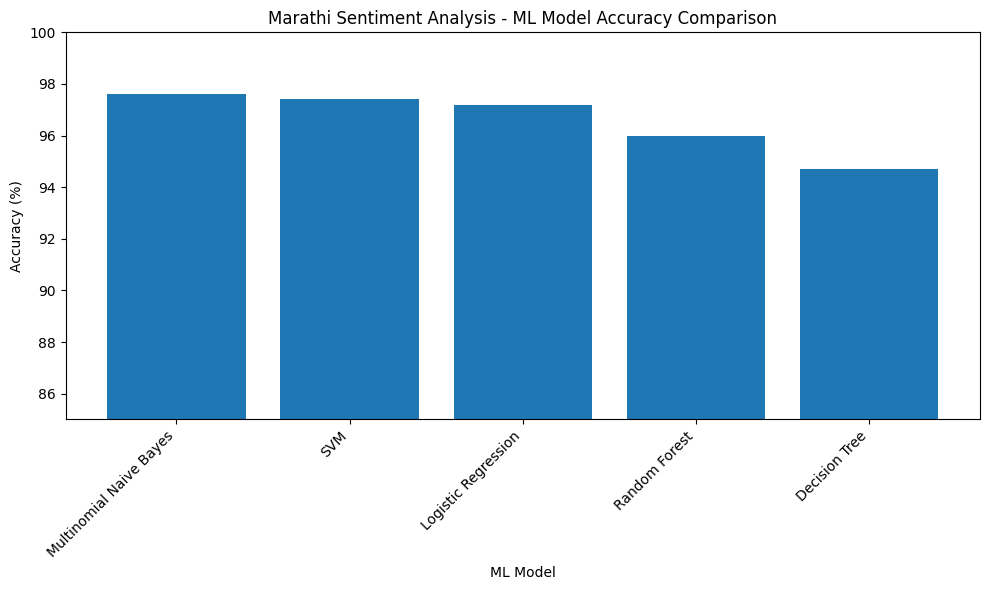

In [92]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df['Model'],
    results_df['Accuracy'] * 100
)

plt.xlabel('ML Model')
plt.ylabel('Accuracy (%)')
plt.title('Marathi Sentiment Analysis - ML Model Accuracy Comparison')

plt.xticks(rotation=45, ha='right')
plt.ylim(85, 100)

plt.tight_layout()

plt.savefig(
    'sentiment_ml_accuracy_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

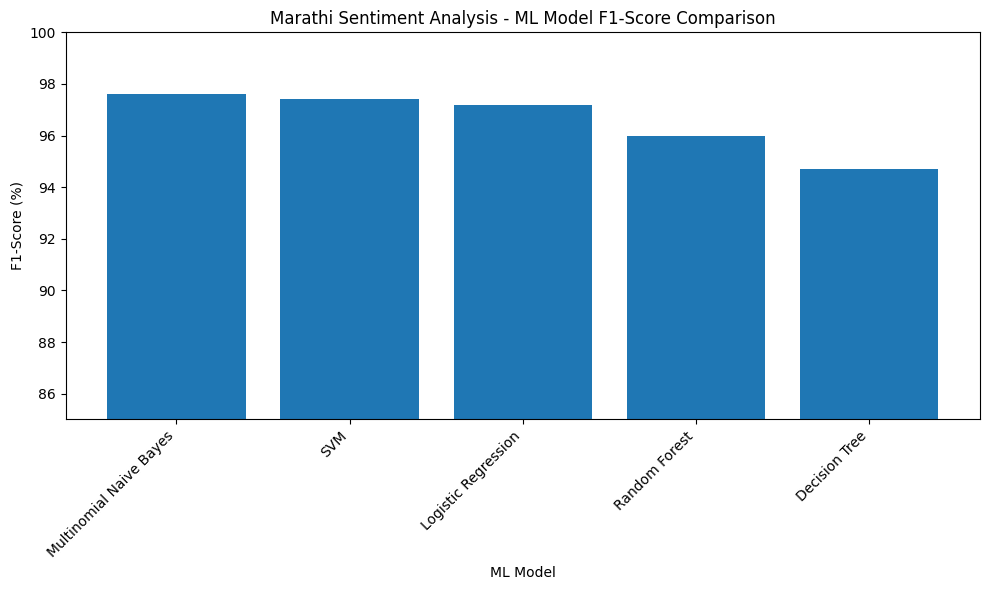

In [93]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df['Model'],
    results_df['F1-Score'] * 100
)

plt.xlabel('ML Model')
plt.ylabel('F1-Score (%)')
plt.title('Marathi Sentiment Analysis - ML Model F1-Score Comparison')

plt.xticks(rotation=45, ha='right')
plt.ylim(85, 100)

plt.tight_layout()

plt.savefig(
    'sentiment_ml_f1_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

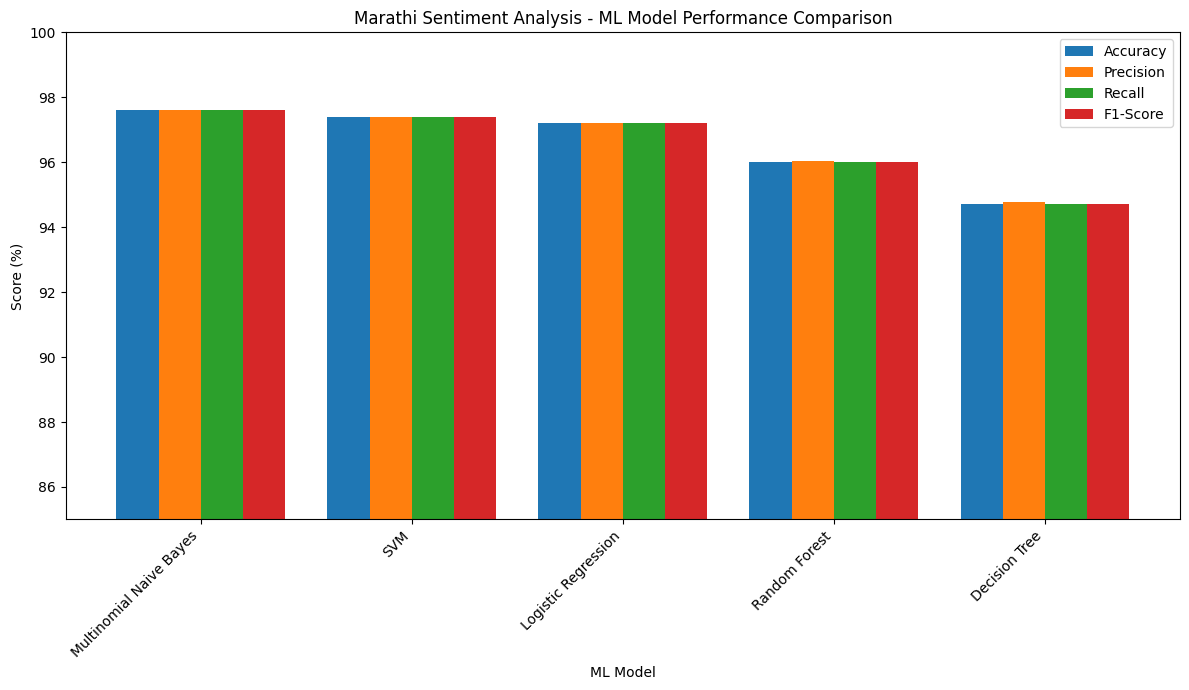

In [94]:
metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
]

x = np.arange(len(results_df['Model']))
width = 0.2

plt.figure(figsize=(12, 7))

plt.bar(
    x - 1.5 * width,
    results_df['Accuracy'] * 100,
    width,
    label='Accuracy'
)

plt.bar(
    x - 0.5 * width,
    results_df['Precision'] * 100,
    width,
    label='Precision'
)

plt.bar(
    x + 0.5 * width,
    results_df['Recall'] * 100,
    width,
    label='Recall'
)

plt.bar(
    x + 1.5 * width,
    results_df['F1-Score'] * 100,
    width,
    label='F1-Score'
)

plt.xlabel('ML Model')
plt.ylabel('Score (%)')
plt.title('Marathi Sentiment Analysis - ML Model Performance Comparison')

plt.xticks(
    x,
    results_df['Model'],
    rotation=45,
    ha='right'
)

plt.ylim(85, 100)
plt.legend()

plt.tight_layout()

plt.savefig(
    'sentiment_ml_all_metrics_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [95]:
from google.colab import files

files.download('sentiment_ml_accuracy_comparison.png')
files.download('sentiment_ml_f1_comparison.png')
files.download('sentiment_ml_all_metrics_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>